In [1]:
!pip install tensorflow
import pandas as pd
import numpy as np
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
with open("styles.csv", encoding='utf-8') as f:
    lines = f.readlines()
    print(lines[6043])  

44065,Men,Personal Care,Fragrance,Perfume and Body Mist,Blue,Spring,2017,Casual,Boss Men Perfume, After Shave Balm and Shower Gel Set



In [3]:
df = pd.read_csv("styles.csv", on_bad_lines='skip')

In [4]:
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
print(df['masterCategory'].value_counts())

(44424, 10)
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']
id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64
masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64


In [5]:
relevant_categories = ['Apparel', 'Accessories', 'Footwear']
df = df[df['masterCategory'].isin(relevant_categories)].reset_index(drop=True)
print(df.shape)
print(df['subCategory'].value_counts())

(41890, 10)
subCategory
Topwear                     15402
Shoes                        7343
Bags                         3055
Bottomwear                   2694
Watches                      2542
Innerwear                    1808
Jewellery                    1079
Eyewear                      1073
Sandal                        963
Wallets                       933
Flip Flops                    913
Belts                         811
Socks                         698
Dress                         478
Loungewear and Nightwear      470
Saree                         427
Headwear                      293
Ties                          258
Accessories                   129
Scarves                       118
Cufflinks                     108
Apparel Set                   106
Stoles                         90
Mufflers                       38
Shoe Accessories               24
Gloves                         20
Water Bottle                    7
Umbrellas                       6
Sports Accessories      

In [6]:
slot_map = {
    'Topwear': 'top',
    'Dress': 'top',
    'Apparel Set': 'top',
    'Bottomwear': 'bottom',
    'Shoes': 'footwear',
    'Sandal': 'footwear',
    'Flip Flops': 'footwear',
    'Bags': 'accessory',
    'Watches': 'accessory',
    'Jewellery': 'accessory',
    'Eyewear': 'accessory',
    'Belts': 'accessory',
    'Scarves': 'accessory',
    'Headwear': 'accessory'
}

df['slot'] = df['subCategory'].map(slot_map)
df_outfit = df.dropna(subset=['slot']).reset_index(drop=True)

print(df_outfit.shape)
print(df_outfit['slot'].value_counts())

(36870, 11)
slot
top          15986
footwear      9219
accessory     8971
bottom        2694
Name: count, dtype: int64


In [7]:
import os

image_dir = r"C:\Users\bansa\Downloads\archive (7)\images"

sample_ids = df_outfit['id'].head(5).tolist()
for i in sample_ids:
    path = os.path.join(image_dir, f"{i}.jpg")
    print(path, os.path.exists(path))

C:\Users\bansa\Downloads\archive (7)\images\15970.jpg True
C:\Users\bansa\Downloads\archive (7)\images\39386.jpg True
C:\Users\bansa\Downloads\archive (7)\images\59263.jpg True
C:\Users\bansa\Downloads\archive (7)\images\21379.jpg True
C:\Users\bansa\Downloads\archive (7)\images\53759.jpg True


In [8]:
df_outfit['image_path'] = df_outfit['id'].apply(lambda x: os.path.join(image_dir, f"{x}.jpg"))

# check how many images actually exist for the full dataset
df_outfit['image_exists'] = df_outfit['image_path'].apply(os.path.exists)
print(df_outfit['image_exists'].value_counts())

# keep only rows with existing images
df_outfit = df_outfit[df_outfit['image_exists']].reset_index(drop=True)
df_outfit = df_outfit.drop(columns=['image_exists'])
print(df_outfit.shape)

image_exists
True     36865
False        5
Name: count, dtype: int64
(36865, 12)


In [9]:
# load pretrained ResNet50, remove the final classification layer
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

print(base_model.output_shape)

(None, 2048)


In [10]:
from tqdm import tqdm

def load_and_preprocess(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

def extract_embeddings(df, batch_size=64):
    embeddings = []
    paths = df['image_path'].tolist()
    
    for i in tqdm(range(0, len(paths), batch_size)):
        batch_paths = paths[i:i+batch_size]
        batch_images = np.vstack([load_and_preprocess(p) for p in batch_paths])
        batch_embeddings = base_model.predict(batch_images, verbose=0)
        embeddings.append(batch_embeddings)
    
    return np.vstack(embeddings)

In [11]:
# balanced sample: ~2500 per slot
sample_df = df_outfit.groupby('slot', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 2500), random_state=42)
).reset_index(drop=True)

print(sample_df['slot'].value_counts())
print(sample_df.shape)

slot
accessory    2500
bottom       2500
footwear     2500
top          2500
Name: count, dtype: int64
(10000, 12)


C:\Users\bansa\AppData\Local\Temp\ipykernel_15132\114503915.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df_outfit.groupby('slot', group_keys=False).apply(


In [13]:
embeddings = extract_embeddings(sample_df, batch_size=64)
print(embeddings.shape)

100%|████████████████████████████████████████████████████████████████████████████████| 157/157 [22:58<00:00,  8.78s/it]

(10000, 2048)


In [14]:
import numpy as np

np.save("embeddings.npy", embeddings)
sample_df.to_csv("sample_df.csv", index=False)

print("Saved successfully")

Saved successfully


In [17]:
from sklearn.metrics.pairwise import cosine_similarity

# reload if needed (skip if still in memory)
# embeddings = np.load("embeddings.npy")
# sample_df = pd.read_csv("sample_df.csv")

def recommend_matching_items(item_index, target_slot, top_n=5):
    item_embedding = embeddings[item_index].reshape(1, -1)
    
    # only compare against items in the target slot (e.g., if input is a 'top', recommend 'bottom')
    candidate_indices = sample_df[sample_df['slot'] == target_slot].index.tolist()
    candidate_embeddings = embeddings[candidate_indices]
    
    similarities = cosine_similarity(item_embedding, candidate_embeddings)[0]
    
    top_matches = np.argsort(similarities)[::-1][:top_n]
    result_indices = [candidate_indices[i] for i in top_matches]
    
    return sample_df.iloc[result_indices][['id', 'productDisplayName', 'slot', 'image_path']]

In [16]:
# pick a random 'top' item and find matching 'bottom' items
top_item_index = sample_df[sample_df['slot'] == 'top'].index[0]
print("Selected item:", sample_df.iloc[top_item_index]['productDisplayName'])

recommendations = recommend_matching_items(top_item_index, target_slot='bottom', top_n=5)
print(recommendations)

Selected item: United Colors of Benetton Men Summer Blue T-shirt
         id                             productDisplayName    slot  \
4685   2562                   Nabaiji Women Black Swimsuit  bottom   
3521   7070  Timberland Men's Cycling Pod Chino Khaki Pant  bottom   
4051   3511         ADIDAS Men's Dark Navy White Tracksuit  bottom   
3898  16230         Puma Men Tricot Graphic Grey Tracksuit  bottom   
3680   4815          ADIDAS Men's AP ST Black White Shorts  bottom   

                                             image_path  
4685  C:\Users\bansa\Downloads\archive (7)\images\25...  
3521  C:\Users\bansa\Downloads\archive (7)\images\70...  
4051  C:\Users\bansa\Downloads\archive (7)\images\35...  
3898  C:\Users\bansa\Downloads\archive (7)\images\16...  
3680  C:\Users\bansa\Downloads\archive (7)\images\48...  


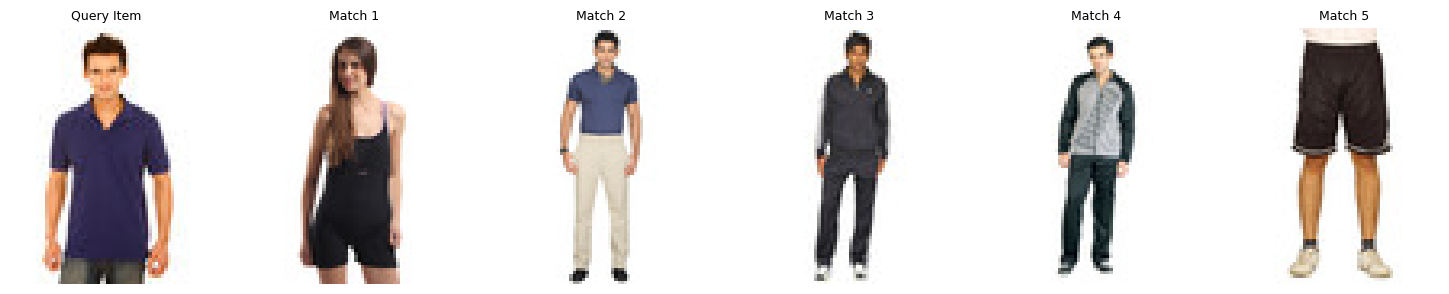

In [18]:
import matplotlib.pyplot as plt
from PIL import Image

def show_recommendations(item_index, target_slot, top_n=5):
    fig, axes = plt.subplots(1, top_n + 1, figsize=(15, 3))
    
    # show the selected item first
    query_img = Image.open(sample_df.iloc[item_index]['image_path'])
    axes[0].imshow(query_img)
    axes[0].set_title("Query Item", fontsize=9)
    axes[0].axis('off')
    
    recommendations = recommend_matching_items(item_index, target_slot, top_n)
    
    for i, (_, row) in enumerate(recommendations.iterrows()):
        img = Image.open(row['image_path'])
        axes[i+1].imshow(img)
        axes[i+1].set_title(f"Match {i+1}", fontsize=9)
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()

show_recommendations(top_item_index, target_slot='bottom', top_n=5)

In [19]:
def recommend_matching_items_v2(item_index, target_slot, top_n=5):
    query_item = sample_df.iloc[item_index]
    item_embedding = embeddings[item_index].reshape(1, -1)
    
    # Start with target slot candidates
    candidates = sample_df[sample_df['slot'] == target_slot].copy()
    
    # Rule 1: match gender (avoid Men's top with Women's bottom, etc.)
    if query_item['gender'] in ['Men', 'Women']:
        candidates = candidates[candidates['gender'].isin([query_item['gender'], 'Unisex'])]
    
    # Rule 2: avoid clashing colors (simple heuristic - exclude exact loud clashes)
    clashing = {
        'Red': ['Pink', 'Orange'],
        'Pink': ['Red', 'Orange'],
    }
    query_color = query_item['baseColour']
    if query_color in clashing:
        candidates = candidates[~candidates['baseColour'].isin(clashing[query_color])]
    
    if len(candidates) == 0:
        return pd.DataFrame()  # no matches after filtering
    
    candidate_indices = candidates.index.tolist()
    candidate_embeddings = embeddings[candidate_indices]
    
    similarities = cosine_similarity(item_embedding, candidate_embeddings)[0]
    top_matches = np.argsort(similarities)[::-1][:top_n]
    result_indices = [candidate_indices[i] for i in top_matches]
    
    return sample_df.iloc[result_indices][['id', 'gender', 'baseColour', 'productDisplayName', 'slot', 'image_path']]

In [20]:
recommendations_v2 = recommend_matching_items_v2(top_item_index, target_slot='bottom', top_n=5)
print(recommendations_v2)

         id gender baseColour                             productDisplayName  \
3521   7070    Men      Cream  Timberland Men's Cycling Pod Chino Khaki Pant   
4051   3511    Men       Blue         ADIDAS Men's Dark Navy White Tracksuit   
3898  16230    Men       Grey         Puma Men Tricot Graphic Grey Tracksuit   
3680   4815    Men      Black          ADIDAS Men's AP ST Black White Shorts   
4945   3508    Men      White             ADIDAS Men's White Black Tracksuit   

        slot                                         image_path  
3521  bottom  C:\Users\bansa\Downloads\archive (7)\images\70...  
4051  bottom  C:\Users\bansa\Downloads\archive (7)\images\35...  
3898  bottom  C:\Users\bansa\Downloads\archive (7)\images\16...  
3680  bottom  C:\Users\bansa\Downloads\archive (7)\images\48...  
4945  bottom  C:\Users\bansa\Downloads\archive (7)\images\35...  


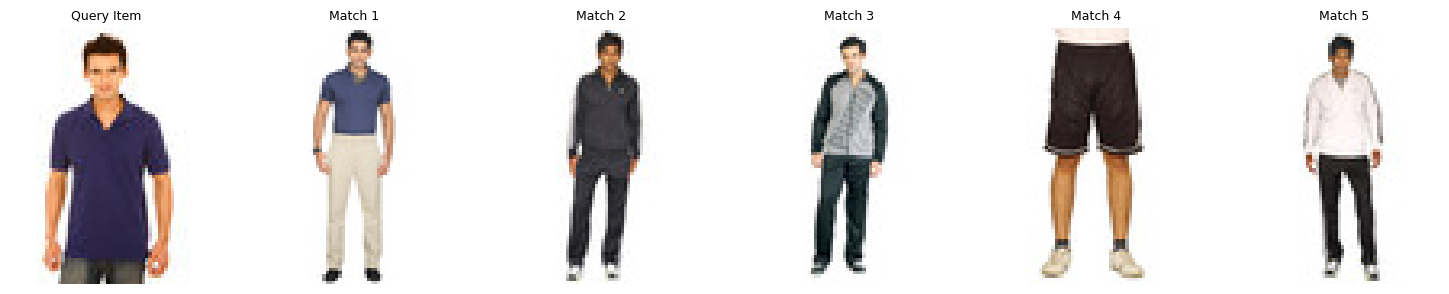

In [21]:
def show_recommendations_v2(item_index, target_slot, top_n=5):
    fig, axes = plt.subplots(1, top_n + 1, figsize=(15, 3))
    
    query_img = Image.open(sample_df.iloc[item_index]['image_path'])
    axes[0].imshow(query_img)
    axes[0].set_title("Query Item", fontsize=9)
    axes[0].axis('off')
    
    recommendations = recommend_matching_items_v2(item_index, target_slot, top_n)
    
    for i, (_, row) in enumerate(recommendations.iterrows()):
        img = Image.open(row['image_path'])
        axes[i+1].imshow(img)
        axes[i+1].set_title(f"Match {i+1}", fontsize=9)
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()

show_recommendations_v2(top_item_index, target_slot='bottom', top_n=5)

Selected item: HM Women Black Sandals


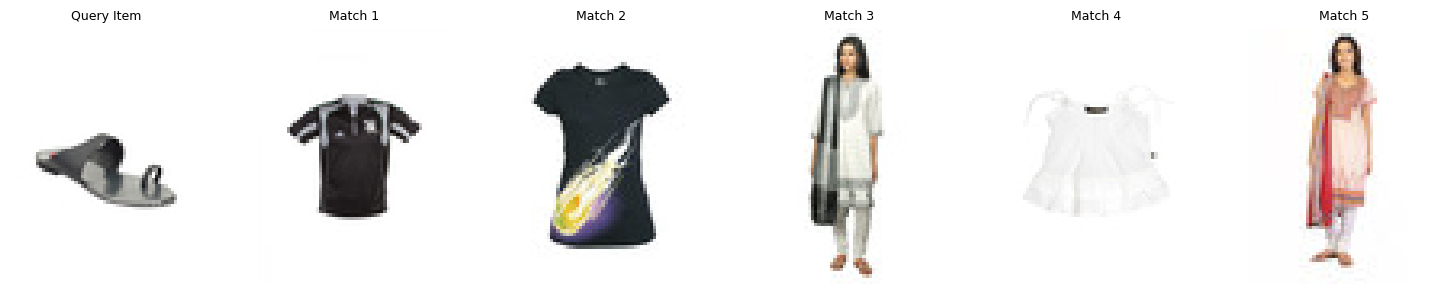

In [22]:
# try another item - pick a footwear item and recommend tops
footwear_index = sample_df[sample_df['slot'] == 'footwear'].index[5]
print("Selected item:", sample_df.iloc[footwear_index]['productDisplayName'])
show_recommendations_v2(footwear_index, target_slot='top', top_n=5)

In [23]:
!pip install streamlit

  Using cached protobuf-6.33.6-cp310-abi3-win_amd64.whl.metadata (593 bytes)
Using cached protobuf-6.33.6-cp310-abi3-win_amd64.whl (437 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.36.2
    Uninstalling protobuf-7.36.2:
      Successfully uninstalled protobuf-7.36.2


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
print(os.getcwd())

C:\Users\bansa\Fashion Project


In [1]:
st.set_page_config(page_title="Fashion Outfit Recommender", layout="wide", page_icon="👗")

NameError: name 'st' is not defined